# Predicted Speed vs Ground Truth

Finds a PIE test-split sequence where the ego vehicle comes to a stop, then looks back up to ~30 seconds
(300 frames at ~10 fps) before that stop point and runs a sliding 15-frame window through the full
pre-stop runway, predicting ego speed at every step alongside ground truth.

Run from the project root: `CS7180-Final/`

In [106]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.11.0+cpu


In [107]:
# ── Load raw PIE trajectory sequences (test split) ────────────────────────
# seq_type="trajectory" gives full-length tracks (longer than "crossing" clips),
# which is needed to have a meaningful pre-stop runway to predict over.
import sys
sys.path.insert(0, str(PROJECT_ROOT / "data"))
from pie_data import PIE
from data.dataset import _normalize_bbox, MAX_SPEED_KMH

PIE_PATH = str(PROJECT_ROOT / "data" / "pie")
pie = PIE(data_path=PIE_PATH)
raw = pie.generate_data_trajectory_sequence("test", seq_type="trajectory", data_split_type="default")

print(f"Test sequences: {len(raw['bbox'])}")

PIE path: ..\data\pie
---------------------------------------------------------
Generating trajectory sequence data
fstride: 1
sample_type: all
height_rng: [0, inf]
squarify_ratio: 0
data_split_type: default
seq_type: trajectory
min_track_size: 15
random_params: {'ratios': None, 'val_data': True, 'regen_data': False}
kfold_params: {'num_folds': 5, 'fold': 1}
---------------------------------------------------------
Generating database for pie
pie annotations loaded from c:\Users\Ahad Imran\Desktop\CS7180-Final\data\pie\data_cache\pie_database.pkl
---------------------------------------------------------
Generating trajectory data
Subset: test
Number of pedestrians: 719 
Total number of samples: 719 
Test sequences: 719


In [108]:
# ── Find all qualifying sequences and display top 7 ────────────────────────
OBS_LEN       = 15
STOP_KMH      = 5.0    # frames at or below this are considered "stopped"
PIE_FPS       = 10     # PIE annotation frame rate
RUNWAY_SECS   = 20    # seconds to look back from the stop point
RUNWAY_FRAMES = PIE_FPS * RUNWAY_SECS
TOP_N         = 7      # number of candidates to display

all_candidates = []
for i in range(len(raw["bbox"])):
    speeds = np.array(raw["obd_speed"][i], dtype=np.float32).flatten()
    track  = np.array(raw["bbox"][i],      dtype=np.float32)

    if speeds.min() > STOP_KMH:
        continue

    stop_idx = int(np.where(speeds <= STOP_KMH)[0][0])

    if stop_idx < RUNWAY_FRAMES + OBS_LEN:
        continue

    pre_stop_max = float(speeds[max(0, stop_idx - RUNWAY_FRAMES) : stop_idx].max())
    all_candidates.append({
        "idx":          i,
        "track":        track,
        "speeds":       speeds,
        "stop_idx":     stop_idx,
        "pre_stop_max": pre_stop_max,
    })

assert all_candidates, (
    f"No sequences found with ≥{RUNWAY_SECS}s before the stop. "
    "Try reducing RUNWAY_SECS."
)

# Sort by highest pre-stop speed (most dramatic braking event first)
all_candidates.sort(key=lambda c: c["pre_stop_max"], reverse=True)
top_candidates = all_candidates[:TOP_N]

print(f"Top {len(top_candidates)} qualifying sequences (ranked by pre-stop speed):\n")
print(f"  {'Rank':<6} {'Seq#':<8} {'Frames':<10} {'Stop@':<10} {'Runway':<16} {'MaxSpeed'}")
print("  " + "-" * 62)
for rank, c in enumerate(top_candidates):
    runway_start = c["stop_idx"] - RUNWAY_FRAMES
    print(f"  [{rank}]   {c['idx']:<8} {len(c['track']):<10} "
          f"{c['stop_idx']:<10} {runway_start}→{c['stop_idx']:<10} "
          f"{c['pre_stop_max']:.1f} km/h")

# Default: pick rank 0 (highest speed)
candidate = top_candidates[0]
print(f"\nAuto-selected: rank [0] — sequence #{candidate['idx']} "
      f"({candidate['pre_stop_max']:.1f} km/h)")

Top 7 qualifying sequences (ranked by pre-stop speed):

  Rank   Seq#     Frames     Stop@      Runway           MaxSpeed
  --------------------------------------------------------------
  [0]   186      614        328        128→328        42.0 km/h
  [1]   266      621        325        125→325        36.0 km/h
  [2]   267      2364       307        107→307        36.0 km/h
  [3]   148      485        241        41→241        32.0 km/h
  [4]   78       2500       283        83→283        30.0 km/h
  [5]   59       688        268        68→268        28.0 km/h
  [6]   77       600        327        127→327        28.0 km/h

Auto-selected: rank [0] — sequence #186 (42.0 km/h)


In [109]:
# ── (Optional) Override: pick by rank from the printed list above ──────────
# Set PICK to a rank index 0–6 from the table above (None = keep rank 0).
PICK = 1

if PICK is not None:
    assert 0 <= PICK < len(top_candidates), \
        f"PICK must be between 0 and {len(top_candidates) - 1}"
    candidate = top_candidates[PICK]

stop_idx = candidate["stop_idx"]
runway_start = max(0, stop_idx - RUNWAY_FRAMES)
print(f"Using rank [{top_candidates.index(candidate)}] — sequence #{candidate['idx']}")
print(f"  Total frames      : {len(candidate['track'])}")
print(f"  Stop at frame     : {stop_idx}")
print(f"  Pre-stop max speed: {candidate['pre_stop_max']:.1f} km/h")
print(f"  Runway window     : frames {runway_start} → {stop_idx}  ({(stop_idx - runway_start) / PIE_FPS:.1f}s)")
print(f"  Runway window: frames {max(0, stop_idx - RUNWAY_FRAMES)} → {stop_idx}")

Using rank [1] — sequence #266
  Total frames      : 621
  Stop at frame     : 325
  Pre-stop max speed: 36.0 km/h
  Runway window     : frames 125 → 325  (20.0s)
  Runway window: frames 125 → 325


In [110]:
# ── Load both trained models ───────────────────────────────────────────────
from pipeline.speed_predictor import SpeedPredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = SpeedPredictor(
    intention_weights=str(PROJECT_ROOT / "weights" / "intention_lstm_best.pt"),
    speed_weights=str(PROJECT_ROOT / "weights" / "speed_lstm_best.pt"),
    device=DEVICE,
)
print(f"Models loaded on {DEVICE}.")

Models loaded on cpu.


In [111]:
# ── Slide window through the pre-stop runway with stride=1 ────────────────
# Slice from (stop_idx - RUNWAY_FRAMES) to (stop_idx + TAIL_SECS) so the
# video shows what happens after the vehicle stops too.
TAIL_SECS  = 10
TAIL_FRAMES = PIE_FPS * TAIL_SECS

runway_start = max(0, candidate["stop_idx"] - RUNWAY_FRAMES)
runway_end   = min(len(candidate["track"]), candidate["stop_idx"] + TAIL_FRAMES)

track  = candidate["track"][runway_start : runway_end]
speeds = candidate["speeds"][runway_start : runway_end]
T      = len(track)

print(f"Runway: {T} frames ({T / PIE_FPS:.1f} s)  →  {T - OBS_LEN + 1} prediction windows")

pred_speeds    = []
gt_speeds      = []
frame_idx      = []
crossing_probs = []

for start in range(0, T - OBS_LEN + 1):
    end         = start + OBS_LEN
    bbox_window = _normalize_bbox(track[start:end])   # (OBS_LEN, 4) normalised

    pred_kmh, crossing_prob = predictor.predict(bbox_window)
    gt_kmh = float(speeds[end - 1])

    pred_speeds.append(pred_kmh)
    gt_speeds.append(gt_kmh)
    crossing_probs.append(crossing_prob)
    frame_idx.append(end - 1)

crossing_probs = np.array(crossing_probs)
pred_speeds    = np.array(pred_speeds)
gt_speeds      = np.array(gt_speeds)
frame_idx      = np.array(frame_idx)

mae  = np.abs(pred_speeds - gt_speeds).mean()
rmse = np.sqrt(((pred_speeds - gt_speeds) ** 2).mean())
print(f"Windows: {len(pred_speeds)}")
print(f"MAE:  {mae:.2f} km/h")
print(f"RMSE: {rmse:.2f} km/h")

Runway: 300 frames (30.0 s)  →  286 prediction windows
Windows: 286
MAE:  6.22 km/h
RMSE: 8.47 km/h


MAE  raw:      6.22 km/h
MAE  smoothed: 6.16 km/h
RMSE smoothed: 8.33 km/h


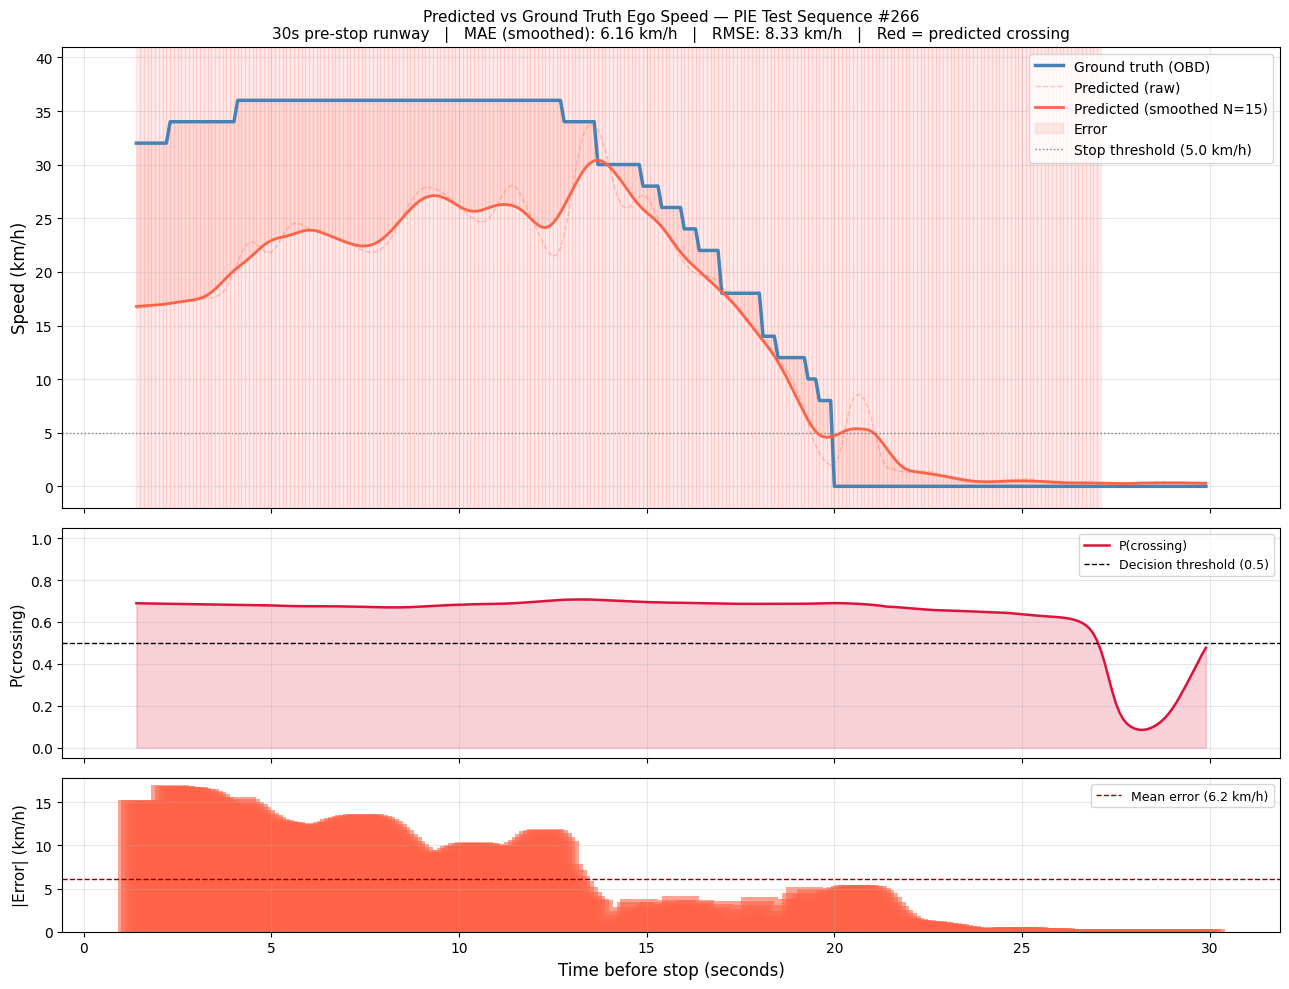

Plot saved to notebooks/speed_prediction_plot.png


In [112]:
# ── Smooth predicted speeds with a rolling average ─────────────────────────
SMOOTH_N = 15   # window size — increase for more smoothing

# Convert frame indices to seconds for a human-readable x-axis
frame_idx   = np.array(frame_idx) / PIE_FPS
pred_speeds = np.array(pred_speeds)
gt_speeds   = np.array(gt_speeds)

kernel          = np.ones(SMOOTH_N) / SMOOTH_N
pred_smoothed   = np.convolve(pred_speeds, kernel, mode='same')

# Fix edge artifacts: for the first and last SMOOTH_N//2 frames use a shorter window
half = SMOOTH_N // 2
for i in range(half):
    pred_smoothed[i]      = pred_speeds[:i + half + 1].mean()
    pred_smoothed[-(i+1)] = pred_speeds[-(i + half + 1):].mean()

# Recompute metrics on smoothed predictions
mae_raw      = np.abs(pred_speeds - gt_speeds).mean()
mae_smoothed = np.abs(pred_smoothed - gt_speeds).mean()
rmse_smoothed = np.sqrt(((pred_smoothed - gt_speeds) ** 2).mean())
print(f"MAE  raw:      {mae_raw:.2f} km/h")
print(f"MAE  smoothed: {mae_smoothed:.2f} km/h")
print(f"RMSE smoothed: {rmse_smoothed:.2f} km/h")

# ── Plot predicted vs ground truth + crossing intention ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.5, 1]})

# ── Top: speed comparison ──────────────────────────────────────────────────
ax = axes[0]
# Shade background red where model predicts crossing
crossing_mask = crossing_probs > 0.5
for i in range(len(frame_idx) - 1):
    if crossing_mask[i]:
        ax.axvspan(frame_idx[i], frame_idx[i+1], alpha=0.07, color="red")

ax.plot(frame_idx, gt_speeds,    label="Ground truth (OBD)",              linewidth=2.5, color="steelblue")
ax.plot(frame_idx, pred_speeds,  label="Predicted (raw)",                  linewidth=1.0,
        color="tomato", linestyle="--", alpha=0.35)
ax.plot(frame_idx, pred_smoothed, label=f"Predicted (smoothed N={SMOOTH_N})", linewidth=2.0,
        color="tomato")
ax.fill_between(frame_idx, gt_speeds, pred_smoothed, alpha=0.12, color="tomato", label="Error")
ax.axhline(STOP_KMH, color="gray", linestyle=":", linewidth=1,
           label=f"Stop threshold ({STOP_KMH} km/h)")
ax.set_ylabel("Speed (km/h)", fontsize=12)
ax.set_title(
    f"Predicted vs Ground Truth Ego Speed — PIE Test Sequence #{candidate['idx']}\n"
    f"{T / PIE_FPS:.0f}s pre-stop runway   |   MAE (smoothed): {mae_smoothed:.2f} km/h   |   RMSE: {rmse_smoothed:.2f} km/h   |   Red = predicted crossing",
    fontsize=11,
)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim(-2, max(gt_speeds.max(), pred_speeds.max()) + 5)

# ── Middle: crossing intention probability ─────────────────────────────────
ax2 = axes[1]
ax2.plot(frame_idx, crossing_probs, color="crimson", linewidth=1.8, label="P(crossing)")
ax2.fill_between(frame_idx, 0, crossing_probs, alpha=0.2, color="crimson")
ax2.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold (0.5)")
ax2.set_ylabel("P(crossing)", fontsize=11)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, alpha=0.3)

# ── Bottom: absolute speed error ───────────────────────────────────────────
ax3 = axes[2]
abs_err = np.abs(pred_smoothed - gt_speeds)
ax3.bar(frame_idx, abs_err, color="tomato", alpha=0.6, width=1)
ax3.axhline(mae_smoothed, color="darkred", linestyle="--", linewidth=1,
            label=f"Mean error ({mae_smoothed:.1f} km/h)")
ax3.set_ylabel("|Error| (km/h)", fontsize=11)
ax3.set_xlabel("Time before stop (seconds)", fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "notebooks" / "speed_prediction_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to notebooks/speed_prediction_plot.png")

In [113]:
# ── Identify the source video for this sequence ───────────────────────────
# raw["image"][i] is a list of per-frame image paths that encode set + video + frame number.
# Even if the images haven't been extracted yet, the paths still tell us which video to download.

from pathlib import Path as _Path

image_paths   = raw["image"][candidate["idx"]]
sample_path   = _Path(image_paths[0])
set_id        = sample_path.parts[-3]   # e.g. "set02"
video_id      = sample_path.parts[-2]   # e.g. "video_0004"

# Frame numbers at the runway boundaries
runway_images     = image_paths[runway_start : runway_end]
first_frame_num   = int(_Path(runway_images[0]).stem)
last_frame_num    = int(_Path(runway_images[-1]).stem)

# Frame numbers are absolute video frame indices (converted later using real video fps)
start_sec = first_frame_num / PIE_FPS   # placeholder — real timestamps computed in next cell
end_sec   = last_frame_num  / PIE_FPS

clip_path = PROJECT_ROOT / "data" / "pie" / "clips" / set_id / f"{video_id}.mp4"

print("=" * 60)
print(f"  Sequence #{candidate['idx']}")
print(f"  Set   : {set_id}")
print(f"  Video : {video_id}")
print(f"  Frames: {first_frame_num} → {last_frame_num}  ({start_sec:.1f}s → {end_sec:.1f}s)")
print(f"  Full video path (once downloaded):")
print(f"    {clip_path.resolve()}")
print("=" * 60)
print()
print("To download, grab the following file from the PIE dataset release:")
print(f"  clips/{set_id}/{video_id}.mp4")

  Sequence #266
  Set   : set03
  Video : video_0008
  Frames: 5656 → 6022  (565.6s → 602.2s)
  Full video path (once downloaded):
    C:\Users\Ahad Imran\Desktop\CS7180-Final\data\pie\clips\set03\video_0008.mp4

To download, grab the following file from the PIE dataset release:
  clips/set03/video_0008.mp4


In [114]:
# ── Extract runway clip — video file or image frames fallback ──────────────
# NOTE: first_frame_num / last_frame_num are ABSOLUTE frame indices in the
# original video (which runs at ~30fps), NOT at the 10fps annotation stride.
# We probe the real fps with ffprobe before computing timestamps.
import subprocess
import shutil

OUTPUT_CLIP = PROJECT_ROOT / "notebooks" / f"runway_{set_id}_{video_id}_{first_frame_num}-{last_frame_num}.mp4"
IMAGES_PATH = PROJECT_ROOT / "data" / "pie" / "images" / set_id / video_id

ffmpeg_available = shutil.which("ffmpeg") is not None
if not ffmpeg_available:
    print("ffmpeg not found on PATH. Install from https://ffmpeg.org/download.html")

# ── Method A: trim from downloaded .mp4 ───────────────────────────────────
if ffmpeg_available and clip_path.exists():

    # Probe actual fps + duration
    probe = subprocess.run(
        ["ffprobe", "-v", "error",
         "-select_streams", "v:0",
         "-show_entries", "stream=r_frame_rate,duration",
         "-of", "default=noprint_wrappers=1:nokey=1",
         str(clip_path)],
        capture_output=True, text=True,
    )
    if probe.returncode != 0 or not probe.stdout.strip():
        print("Video appears corrupt — ffprobe failed:")
        print(probe.stderr[-500:])
    else:
        lines = probe.stdout.strip().splitlines()
        num, den   = map(int, lines[0].split("/"))
        video_fps  = num / den
        duration   = float(lines[1])

        # Use real video fps to convert frame indices → timestamps
        start_sec_real = first_frame_num / video_fps
        end_sec_real   = (last_frame_num  / video_fps) 

        print(f"Video fps   : {video_fps:.3f}")
        print(f"Duration    : {duration:.1f}s")
        print(f"Timestamps  : {start_sec_real:.2f}s → {end_sec_real:.2f}s")

        if start_sec_real >= duration:
            print(f"\nERROR: start timestamp ({start_sec_real:.1f}s) exceeds video "
                  f"duration ({duration:.1f}s).")
            print("This usually means the wrong video file was downloaded.")
            print(f"Expected: clips/{set_id}/{video_id}.mp4")
        else:
            cmd = [
                "ffmpeg", "-y",
                "-i",  str(clip_path),
                "-ss", f"{start_sec_real:.4f}",
                "-to", f"{end_sec_real:.4f}",
                "-c:v", "libx264", "-c:a", "copy",
                str(OUTPUT_CLIP),
            ]
            result = subprocess.run(cmd, capture_output=True, text=True)
            if result.returncode == 0:
                size_kb = OUTPUT_CLIP.stat().st_size / 1024
                print(f"Clip saved → {OUTPUT_CLIP.resolve()}  ({size_kb:.1f} KB)")
            else:
                print("ffmpeg trim failed:", result.stderr[-1000:])

# ── Method B: stitch from extracted image frames ──────────────────────────
elif ffmpeg_available and IMAGES_PATH.exists():
    print(f"No .mp4 — building from extracted frames in:\n  {IMAGES_PATH}")
    frame_files = sorted(IMAGES_PATH.glob("*.png"))
    runway_files = [f for f in frame_files
                    if first_frame_num <= int(f.stem) <= last_frame_num]
    print(f"Found {len(runway_files)} frames in range")

    if runway_files:
        list_file = OUTPUT_CLIP.parent / "_frame_list.txt"
        with open(list_file, "w") as fh:
            for f in runway_files:
                fh.write(f"file '{f.resolve()}'\n")
                fh.write(f"duration {1/PIE_FPS:.6f}\n")
        cmd = [
            "ffmpeg", "-y", "-f", "concat", "-safe", "0",
            "-i", str(list_file),
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            str(OUTPUT_CLIP),
        ]
        result = subprocess.run(cmd, capture_output=True, text=True)
        list_file.unlink(missing_ok=True)
        if result.returncode == 0:
            size_kb = OUTPUT_CLIP.stat().st_size / 1024
            print(f"Clip saved → {OUTPUT_CLIP.resolve()}  ({size_kb:.1f} KB)")
        else:
            print("ffmpeg stitch failed:", result.stderr[-1000:])

else:
    print(f"Neither .mp4 nor extracted frames found.")
    print(f"  .mp4 expected at  : {clip_path.resolve()}")
    print(f"  Frames expected at: {IMAGES_PATH.resolve()}")
    print(f"\nDownload: clips/{set_id}/{video_id}.mp4  from the PIE dataset release")

Video fps   : 30.000
Duration    : 600.0s
Timestamps  : 188.53s → 200.73s
Clip saved → C:\Users\Ahad Imran\Desktop\CS7180-Final\notebooks\runway_set03_video_0008_5656-6022.mp4  (15436.0 KB)


In [118]:
# ── Render side-by-side demo video: clip (left) + live speed plot (right) ──
# Requires OUTPUT_CLIP to exist (run the cell above first).
# Output: notebooks/demo_<set>_<video>.mp4
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg

DEMO_OUT = PROJECT_ROOT / "notebooks" / f"demo_{set_id}_{video_id}.mp4"

if not OUTPUT_CLIP.exists():
    print(f"Clip not found at {OUTPUT_CLIP}. Run the extraction cell first.")
else:
    cap = cv2.VideoCapture(str(OUTPUT_CLIP))
    video_fps_out = cap.get(cv2.CAP_PROP_FPS) or PIE_FPS
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    n_preds = len(pred_smoothed)
    print(f"Video: {total_video_frames} frames @ {video_fps_out:.2f} fps  ({W}x{H})")
    print(f"Predictions: {n_preds} windows")

    # Pre-render all plot frames as numpy arrays
    PLOT_W, PLOT_H = W, H
    fig, axes = plt.subplots(2, 1, figsize=(PLOT_W / 100, PLOT_H / 100),
                             gridspec_kw={"height_ratios": [3, 1]}, dpi=100)
    canvas = FigureCanvasAgg(fig)
    ax_speed, ax_intent = axes

    time_axis = np.arange(n_preds) / PIE_FPS   # seconds

    print("Pre-rendering plot frames...", end="", flush=True)
    plot_frames = []
    for t in range(n_preds):
        ax_speed.clear()
        ax_intent.clear()

        ax_speed.plot(time_axis[:t+1], gt_speeds[:t+1],
                      color="steelblue", linewidth=2, label="Ground truth")
        ax_speed.plot(time_axis[:t+1], pred_smoothed[:t+1],
                      color="tomato", linewidth=2, label="Predicted")
        ax_speed.axvline(time_axis[t], color="black", linewidth=1, linestyle="--")
        ax_speed.set_xlim(0, time_axis[-1])
        ax_speed.set_ylim(0, max(gt_speeds.max(), pred_smoothed.max()) * 1.1)
        ax_speed.set_ylabel("Speed (km/h)", fontsize=9)
        ax_speed.legend(fontsize=8, loc="upper right")
        ax_speed.set_title("Ego Speed: Predicted vs Ground Truth", fontsize=9)

        ax_intent.plot(time_axis[:t+1], crossing_probs[:t+1],
                       color="darkorange", linewidth=1.5)
        ax_intent.axvline(time_axis[t], color="black", linewidth=1, linestyle="--")
        ax_intent.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
        ax_intent.set_xlim(0, time_axis[-1])
        ax_intent.set_ylim(0, 1)
        ax_intent.set_ylabel("P(crossing)", fontsize=9)
        ax_intent.set_xlabel("Time (s)", fontsize=9)

        fig.tight_layout(pad=0.5)
        canvas.draw()
        buf = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8)
        buf = buf.reshape(canvas.get_width_height()[::-1] + (4,))   # RGBA
        plot_frames.append(cv2.cvtColor(buf, cv2.COLOR_RGBA2BGR))

    plt.close(fig)
    print(f" done ({len(plot_frames)} frames)")

    # Load YOLO for live pedestrian detection on each frame
    from ultralytics import YOLO as _YOLO
    yolo = _YOLO("yolo26n.pt")
    YOLO_PERSON_CLS = 0   # COCO class 0 = person

    def _yolo_primary_ped(bgr_frame):
        """Return (x1,y1,x2,y2) in pixel coords for the pedestrian closest to centre."""
        results = yolo(bgr_frame, verbose=False)[0]
        best, best_dist = None, float("inf")
        cx_frame, cy_frame = bgr_frame.shape[1] / 2, bgr_frame.shape[0] / 2
        for box in results.boxes:
            if int(box.cls[0]) != YOLO_PERSON_CLS:
                continue
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            d = (cx - cx_frame) ** 2 + (cy - cy_frame) ** 2
            if d < best_dist:
                best_dist = d
                best = (int(x1), int(y1), int(x2), int(y2))
        return best

    # Write output video — map each video frame to the nearest prediction index
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(str(DEMO_OUT), fourcc, video_fps_out, (W * 2, H))

    # PIE GT bboxes kept as fallback if YOLO finds nothing (pixel coords at 1920x1080)
    PIE_W, PIE_H = 1920, 1080
    sx, sy = W / PIE_W, H / PIE_H

    from IPython.display import display
    import ipywidgets as widgets

    prog_bar  = widgets.IntProgress(value=0, min=0, max=total_video_frames,
                                    description="Rendering:", bar_style="info",
                                    layout=widgets.Layout(width="100%"))
    prog_label = widgets.Label(value=f"0 / {total_video_frames} frames")
    display(widgets.HBox([prog_bar, prog_label]))

    video_frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Map video frame → prediction / track index
        pred_idx  = min(int(video_frame_idx * n_preds / max(total_video_frames, 1)),
                        n_preds - 1)
        track_idx = min(int(video_frame_idx * len(track) / max(total_video_frames, 1)),
                        len(track) - 1)

        # ── Bounding box overlay — YOLO live detection ────────────────────
        yolo_bbox = _yolo_primary_ped(frame)
        c_prob = float(crossing_probs[pred_idx])
        box_colour = (0, 100, 255) if c_prob > 0.5 else (0, 200, 80)

        if yolo_bbox is not None:
            px1, py1, px2, py2 = yolo_bbox
            cv2.rectangle(frame, (px1, py1), (px2, py2), box_colour, 2)
            cv2.putText(frame, "YOLO", (px1, py1 - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, box_colour, 1, cv2.LINE_AA)
        else:
            # Fallback to PIE GT bbox if YOLO finds no person
            x1, y1, x2, y2 = track[track_idx]
            px1, py1 = int(x1 * sx), int(y1 * sy)
            px2, py2 = int(x2 * sx), int(y2 * sy)
            cv2.rectangle(frame, (px1, py1), (px2, py2), (128, 128, 128), 1)
            cv2.putText(frame, "GT", (px1, py1 - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1, cv2.LINE_AA)

        # ── HUD text overlay ─────────────────────────────────────────────
        spd   = pred_smoothed[pred_idx]
        gt_s  = gt_speeds[pred_idx]
        label = f"Pred: {spd:.1f} km/h  GT: {gt_s:.1f} km/h  Cross: {c_prob:.2f}"
        cv2.rectangle(frame, (0, 0), (W, 30), (0, 0, 0), -1)   # black bar
        cv2.putText(frame, label, (8, 21),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)

        plot_img = cv2.resize(plot_frames[pred_idx], (W, H))
        combined = np.hstack([frame, plot_img])
        out.write(combined)
        video_frame_idx += 1

        prog_bar.value = video_frame_idx
        prog_label.value = f"{video_frame_idx} / {total_video_frames} frames"

    cap.release()
    out.release()

    size_mb = DEMO_OUT.stat().st_size / (1024 * 1024)
    print(f"Demo video saved → {DEMO_OUT.resolve()}  ({size_mb:.1f} MB)")

Video: 366 frames @ 30.00 fps  (1920x1080)
Predictions: 286 windows
Pre-rendering plot frames... done (286 frames)


Demo video saved → C:\Users\Ahad Imran\Desktop\CS7180-Final\notebooks\demo_set03_video_0008.mp4  (46.1 MB)


In [105]:
# ── Summary statistics ─────────────────────────────────────────────────────
stop_frames = gt_speeds < STOP_KMH
move_frames = ~stop_frames

print("Overall")
print(f"  MAE:  {mae:.2f} km/h")
print(f"  RMSE: {rmse:.2f} km/h")

if stop_frames.any():
    mae_stop = np.abs(pred_speeds[stop_frames] - gt_speeds[stop_frames]).mean()
    print(f"\nWhen vehicle is stopped (GT < {STOP_KMH} km/h) — {stop_frames.sum()} frames")
    print(f"  MAE: {mae_stop:.2f} km/h")

if move_frames.any():
    mae_move = np.abs(pred_speeds[move_frames] - gt_speeds[move_frames]).mean()
    print(f"\nWhen vehicle is moving (GT ≥ {STOP_KMH} km/h) — {move_frames.sum()} frames")
    print(f"  MAE: {mae_move:.2f} km/h")

Overall
  MAE:  6.22 km/h
  RMSE: 8.47 km/h

When vehicle is stopped (GT < 5.0 km/h) — 100 frames
  MAE: 1.28 km/h

When vehicle is moving (GT ≥ 5.0 km/h) — 186 frames
  MAE: 8.88 km/h
